In [1]:
# INSTALACIÓN DE REQUISITOS PREVIOS

from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
requirements_path = REPO_ROOT / "requirements.txt"

%pip install -q -r {requirements_path}

print("Requisitos instalados correctamente.")

Note: you may need to restart the kernel to use updated packages.
Requisitos instalados correctamente.


In [1]:
# INSTALACIÓN DE REQUISITOS PREVIOS

from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
requirements_path = REPO_ROOT / "requirements.txt"

%pip install -q -r {requirements_path}

print("Requisitos instalados correctamente.")

Note: you may need to restart the kernel to use updated packages.
Requisitos instalados correctamente.


# 03. Evaluación interna de diarización y relabeling

Este notebook revisa la consistencia interna de la diarización, el filtrado de segmentos, la selección de anchors, el relabeling y los embeddings generados por el Notebook 01.

Primero restaura desde Google Cloud Storage todos los inputs que falten localmente. No vuelve a ejecutar la diarización ni el relabeling. La reconstrucción de embeddings permanece desactivada por defecto y solo se ejecuta si se activa explícitamente.

## 1. Imports y configuración

In [2]:
# IMPORTS

import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.cloud import storage
from IPython.display import clear_output, display

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import (
    HF_TOKEN,
    EDA_DIR,
    INPUT_DIR,
    OUTPUT_DIR,
    FINAL_RELABEL_DIR,
    EMBEDDING_VECTOR_CSV_DIR,
    GCS_UNAV_CSV_PREFIX,
    GCS_CLEAN_AUDIO_PREFIX,
    GCS_DIARIZATION_OUTPUT_PREFIX,
    GCS_EMBEDDING_VECTOR_PREFIX,
    AUDIO_INVENTORY_PRIVATE_CSV,
    EVALUATION_SUMMARY_CSV,
    EVALUATION_SCORED_SEGMENTS_CSV,
    EVALUATION_VALID_SEGMENTS_CSV,
    EVALUATION_ANCHOR_SEGMENTS_CSV,
    EVALUATION_FINAL_SEGMENTS_CSV,
    EVALUATION_FINAL_MERGED_SEGMENTS_CSV,
    EVALUATION_CHANGED_SEGMENTS_CSV,
    EVALUATION_RELABEL_SUMMARY_CSV,
    EVALUATION_ANCHOR_EMBEDDINGS_CSV,
    EVALUATION_ANCHOR_EMBEDDING_VECTORS_CSV,
    LEGACY_ANCHOR_EMBEDDING_VECTORS_CSV,
    EMBEDDING_MODEL_ID,
    EVALUATION_RANDOM_SEED,
    MAX_PAIRS_PER_IDENTITY,
    MAX_NEGATIVE_PAIRS,
    MAX_OVERLAP_RATIO_FOR_VOICEPRINT,
    MIN_DURATION_FOR_VOICEPRINT,
    MIN_RMS_DBFS_FOR_VOICEPRINT,
    ensure_phase03_directories,
)

from src.identidad_audio import add_audio_keys
from src.io_utils import read_csv_robust
from src.storage_io import (
    ensure_local_file,
    upload_directory,
)
from src.evaluacion_interna_relabeling import (
    prepare_inventory_for_merge,
    merge_inventory_metadata,
    build_audio_quality_table,
    build_overlap_threshold_summary,
    select_voiceprint_segments,
    detect_embedding_columns,
    load_embedding_vector_cache,
    rebuild_anchor_embeddings,
    build_speaker_centroids,
    build_proxy_pairs,
    summarize_proxy_pairs,
    plot_proxy_pair_evaluation,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

print("Imports cargados correctamente.")

Imports cargados correctamente.


In [3]:
# CONFIGURACIÓN DE EJECUCIÓN

ensure_phase03_directories()

# Solo activar si no existe el CSV vectorial del Notebook 01 y se desea
# reconstruir los embeddings desde los audios limpios.
REBUILD_ANCHOR_EMBEDDINGS = False
MAX_ANCHORS_TO_REBUILD = None

random.seed(EVALUATION_RANDOM_SEED)
np.random.seed(EVALUATION_RANDOM_SEED)

print("Configuración cargada.")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FINAL_RELABEL_DIR:", FINAL_RELABEL_DIR)
print("EMBEDDING_VECTOR_CSV_DIR:", EMBEDDING_VECTOR_CSV_DIR)
print("Reconstruir embeddings:", REBUILD_ANCHOR_EMBEDDINGS)

Configuración cargada.
OUTPUT_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs
FINAL_RELABEL_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel
EMBEDDING_VECTOR_CSV_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel/embedding_vectors_csv
Reconstruir embeddings: False


## 2. Restauración y carga de outputs

In [4]:
# CONEXIÓN A GOOGLE CLOUD STORAGE Y RESTAURACIÓN DE INPUTS

gcs_client = storage.Client()

required_diarization_files = [
    EVALUATION_SUMMARY_CSV,
    EVALUATION_SCORED_SEGMENTS_CSV,
    EVALUATION_VALID_SEGMENTS_CSV,
    EVALUATION_ANCHOR_SEGMENTS_CSV,
]

for local_path in required_diarization_files:
    ensure_local_file(
        local_path,
        gcs_client,
        gcs_prefix=GCS_DIARIZATION_OUTPUT_PREFIX,
        base_dir=OUTPUT_DIR,
        required=True,
    )

optional_diarization_files = [
    EVALUATION_FINAL_SEGMENTS_CSV,
    EVALUATION_FINAL_MERGED_SEGMENTS_CSV,
    EVALUATION_CHANGED_SEGMENTS_CSV,
    EVALUATION_RELABEL_SUMMARY_CSV,
    EVALUATION_ANCHOR_EMBEDDINGS_CSV,
    EVALUATION_ANCHOR_EMBEDDING_VECTORS_CSV,
    LEGACY_ANCHOR_EMBEDDING_VECTORS_CSV,
]

for local_path in optional_diarization_files:
    ensure_local_file(
        local_path,
        gcs_client,
        gcs_prefix=GCS_DIARIZATION_OUTPUT_PREFIX,
        base_dir=OUTPUT_DIR,
        required=False,
    )

ensure_local_file(
    AUDIO_INVENTORY_PRIVATE_CSV,
    gcs_client,
    gcs_prefix=GCS_UNAV_CSV_PREFIX,
    base_dir=EDA_DIR,
    required=False,
)

print("Restauración de inputs terminada.")

Restauración de inputs terminada.


In [5]:
# CARGA DE OUTPUTS PRINCIPALES

df_summary = read_csv_robust(EVALUATION_SUMMARY_CSV)
df_all_scored_segments = read_csv_robust(EVALUATION_SCORED_SEGMENTS_CSV)
df_all_valid_segments = read_csv_robust(EVALUATION_VALID_SEGMENTS_CSV)
df_all_anchor_segments = read_csv_robust(EVALUATION_ANCHOR_SEGMENTS_CSV)

df_final_segments = read_csv_robust(EVALUATION_FINAL_SEGMENTS_CSV)
df_final_merged_segments = read_csv_robust(
    EVALUATION_FINAL_MERGED_SEGMENTS_CSV
)
df_changed_segments = read_csv_robust(EVALUATION_CHANGED_SEGMENTS_CSV)
df_relabel_summary = read_csv_robust(EVALUATION_RELABEL_SUMMARY_CSV)
df_anchor_embeddings = read_csv_robust(
    EVALUATION_ANCHOR_EMBEDDINGS_CSV
)

print("Carga finalizada.")
print("Audios en summary:", len(df_summary))
print("Segmentos puntuados:", len(df_all_scored_segments))
print("Segmentos válidos:", len(df_all_valid_segments))
print("Anchors:", len(df_all_anchor_segments))
print("Segmentos finales relabel:", len(df_final_segments))
print("Embeddings de anchors:", len(df_anchor_embeddings))

Carga finalizada.
Audios en summary: 1198
Segmentos puntuados: 73000
Segmentos válidos: 43867
Anchors: 7038
Segmentos finales relabel: 43493
Embeddings de anchors: 7038


In [6]:
# CARGA E INTEGRACIÓN DE INVENTARIO / METADATA

df_inventory = read_csv_robust(AUDIO_INVENTORY_PRIVATE_CSV)
df_inventory_small = prepare_inventory_for_merge(df_inventory)

tables_to_key = {
    "summary": df_summary,
    "scored": df_all_scored_segments,
    "valid": df_all_valid_segments,
    "anchors": df_all_anchor_segments,
    "final": df_final_segments,
    "final_merged": df_final_merged_segments,
    "changed": df_changed_segments,
    "anchor_embeddings": df_anchor_embeddings,
}

for table_name, dataframe in tables_to_key.items():
    if dataframe is not None and not dataframe.empty:
        tables_to_key[table_name] = add_audio_keys(dataframe)

df_summary = tables_to_key["summary"]
df_all_scored_segments = tables_to_key["scored"]
df_all_valid_segments = tables_to_key["valid"]
df_all_anchor_segments = tables_to_key["anchors"]
df_final_segments = tables_to_key["final"]
df_final_merged_segments = tables_to_key["final_merged"]
df_changed_segments = tables_to_key["changed"]
df_anchor_embeddings = tables_to_key["anchor_embeddings"]

df_summary_meta = merge_inventory_metadata(df_summary, df_inventory_small)
df_all_scored_segments_meta = merge_inventory_metadata(
    df_all_scored_segments,
    df_inventory_small,
)
df_all_valid_segments_meta = merge_inventory_metadata(
    df_all_valid_segments,
    df_inventory_small,
)
df_all_anchor_segments_meta = merge_inventory_metadata(
    df_all_anchor_segments,
    df_inventory_small,
)
df_final_segments_meta = merge_inventory_metadata(
    df_final_segments,
    df_inventory_small,
)
df_anchor_embeddings_meta = merge_inventory_metadata(
    df_anchor_embeddings,
    df_inventory_small,
)

print("Inventario disponible:", not df_inventory_small.empty)
print("Metadata integrada cuando estuvo disponible.")

Inventario disponible: True
Metadata integrada cuando estuvo disponible.


## 3. Métricas internas de diarización

Estas métricas no sustituyen una evaluación formal con DER/JER, pero permiten detectar problemas estructurales: audios sin dos hablantes, microsegmentación, pocos segmentos válidos, exceso de solapamiento o ausencia de anchors.

In [7]:
# RESUMEN GLOBAL

summary_rows = {
    "n_audios_summary": len(df_summary),
    "n_scored_segments": len(df_all_scored_segments),
    "n_valid_segments": len(df_all_valid_segments),
    "n_anchor_segments": len(df_all_anchor_segments),
    "n_final_segments": len(df_final_segments),
    "n_changed_segments": len(df_changed_segments),
}

display(pd.DataFrame([summary_rows]))

,n_audios_summary,n_scored_segments,n_valid_segments,n_anchor_segments,n_final_segments,n_changed_segments
0,1198,73000,43867,7038,43493,3700


,n_audios_summary,n_scored_segments,n_valid_segments,n_anchor_segments,n_final_segments,n_changed_segments
0,1198,73000,43867,7038,43493,3700


In [8]:
# SPEAKERS DETECTADOS POR AUDIO

if "n_speakers" in df_summary.columns:
    display(
        df_summary["n_speakers"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("n_speakers")
        .reset_index(name="n_audios")
    )

    pct_two_speakers = (df_summary["n_speakers"] == 2).mean()
    print(
        "Porcentaje de audios con 2 speakers detectados:",
        f"{pct_two_speakers:.2%}",
    )
else:
    print("No existe columna n_speakers en df_summary.")

,n_speakers,n_audios
0,2,1198


Porcentaje de audios con 2 speakers detectados: 100.00%


,count,mean,std,min,25%,50%,75%,max
n_regular_segments,1198.0,78.482471,27.138451,21.0,59.0,75.0,96.0,211.0
n_scored_segments,1198.0,60.934891,23.205430,16.0,45.0,57.0,73.0,199.0
n_valid_segments,1198.0,36.616861,12.400755,7.0,27.0,36.0,45.0,100.0
n_anchor_segments,1198.0,5.874791,0.496621,2.0,6.0,6.0,6.0,6.0
n_overlap_regions,1198.0,13.732888,9.571807,0.0,7.0,11.5,18.0,68.0


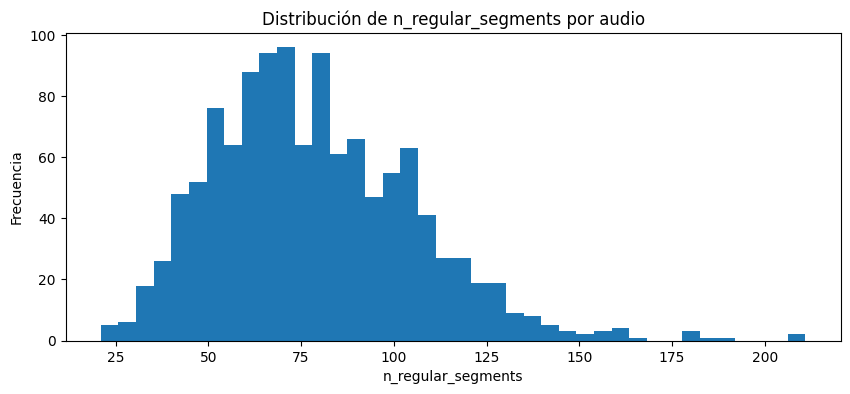

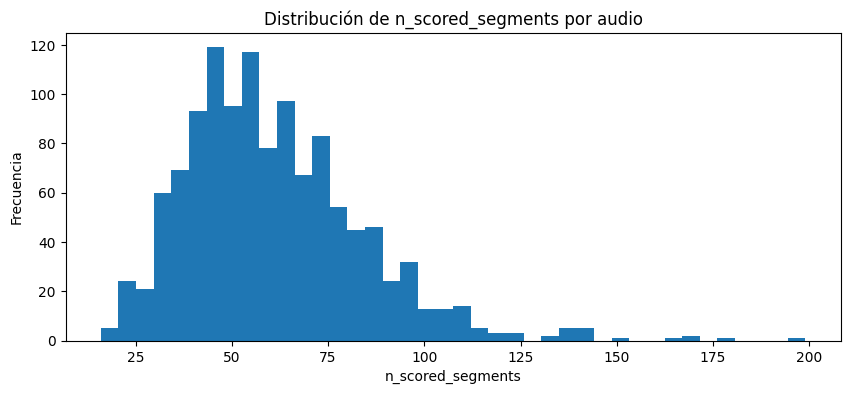

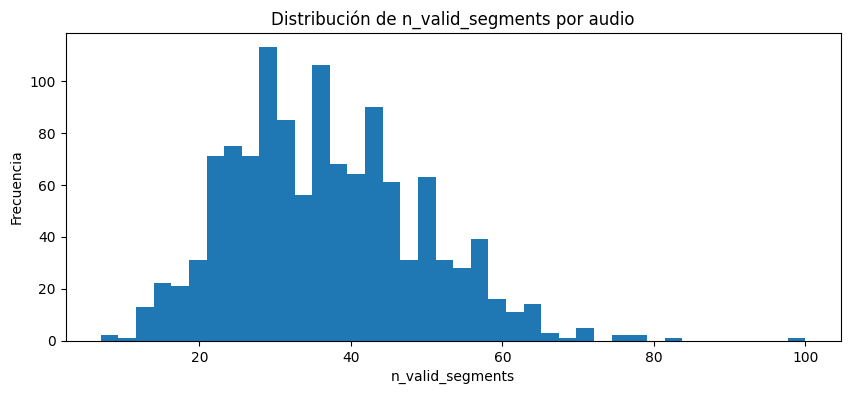

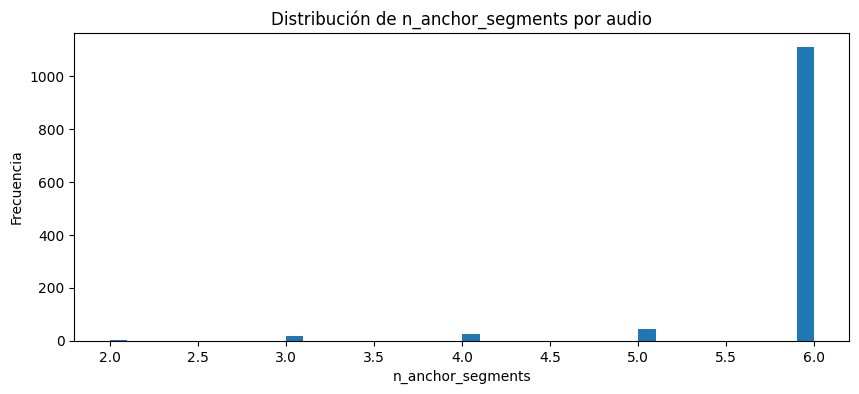

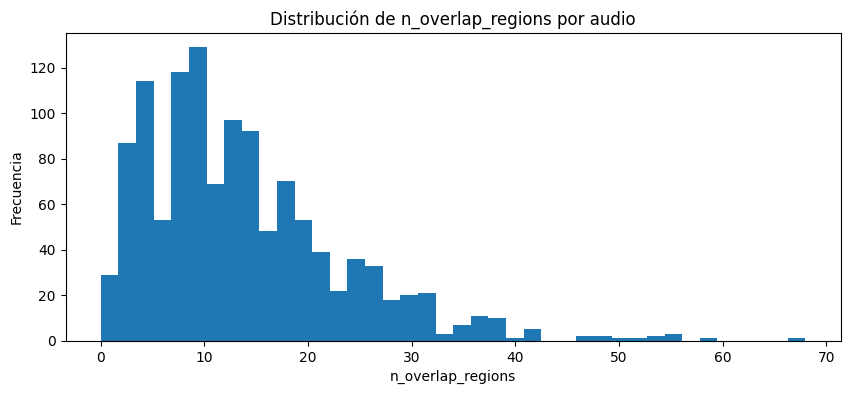

,count,mean,std,min,25%,50%,75%,max
n_regular_segments,1198.0,78.482471,27.138451,21.0,59.0,75.0,96.0,211.0
n_scored_segments,1198.0,60.934891,23.205430,16.0,45.0,57.0,73.0,199.0
n_valid_segments,1198.0,36.616861,12.400755,7.0,27.0,36.0,45.0,100.0
n_anchor_segments,1198.0,5.874791,0.496621,2.0,6.0,6.0,6.0,6.0
n_overlap_regions,1198.0,13.732888,9.571807,0.0,7.0,11.5,18.0,68.0


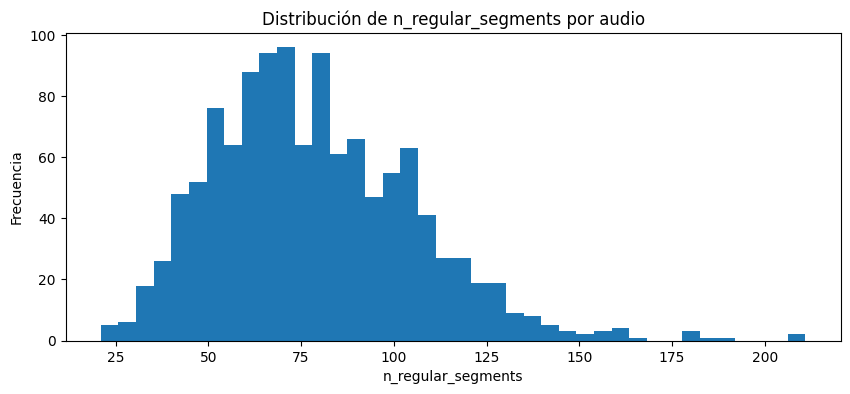

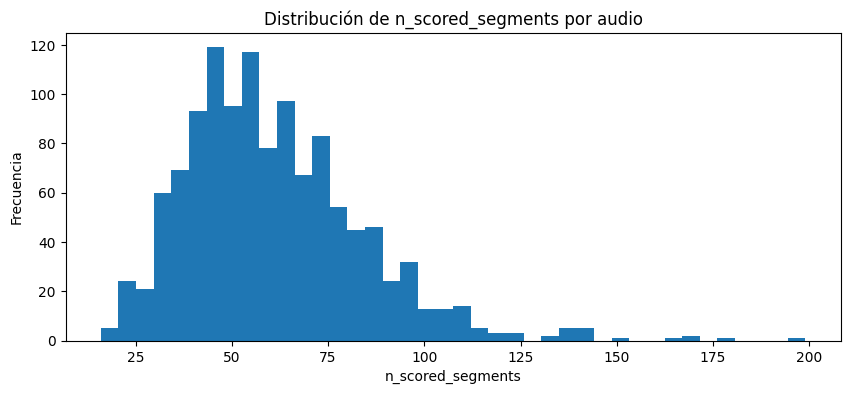

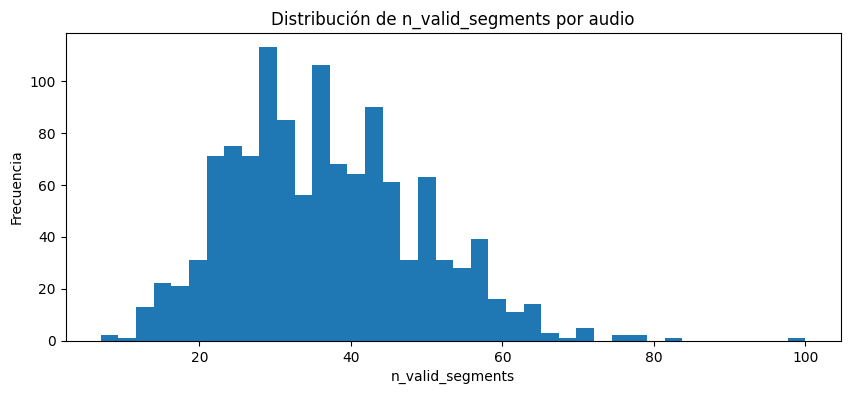

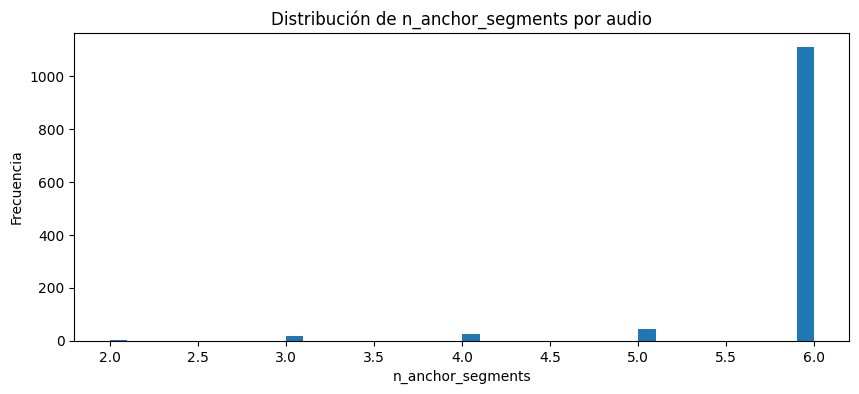

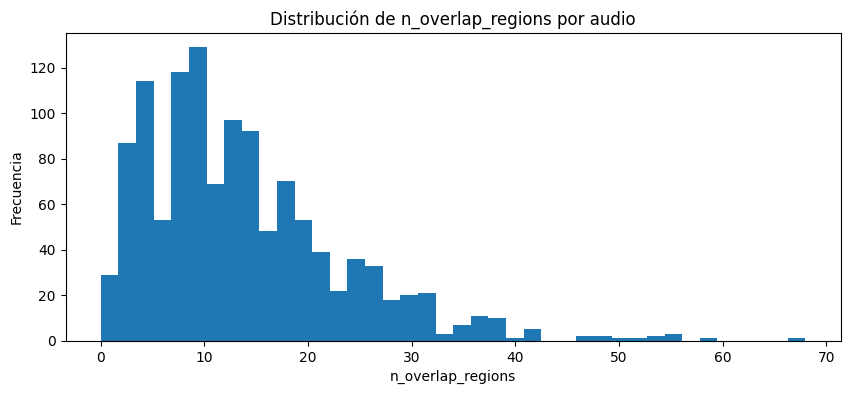

In [9]:
# SEGMENTOS POR AUDIO

segment_count_columns = [
    "n_regular_segments",
    "n_scored_segments",
    "n_valid_segments",
    "n_anchor_segments",
    "n_overlap_regions",
]
segment_count_columns = [
    column
    for column in segment_count_columns
    if column in df_summary.columns
]

if segment_count_columns:
    display(df_summary[segment_count_columns].describe().T)

    for column in segment_count_columns:
        plt.figure(figsize=(10, 4))
        plt.hist(df_summary[column].dropna(), bins=40)
        plt.xlabel(column)
        plt.ylabel("Frecuencia")
        plt.title(f"Distribución de {column} por audio")
        plt.show()
else:
    print("No se encontraron columnas de conteo en df_summary.")

,count,mean,std,min,25%,50%,75%,max
valid_segment_ratio,1198.0,0.616178,0.105948,0.164384,0.54717,0.622222,0.688889,0.916667
anchor_segment_ratio,1198.0,0.110328,0.043056,0.027273,0.08000,0.103448,0.130435,0.352941


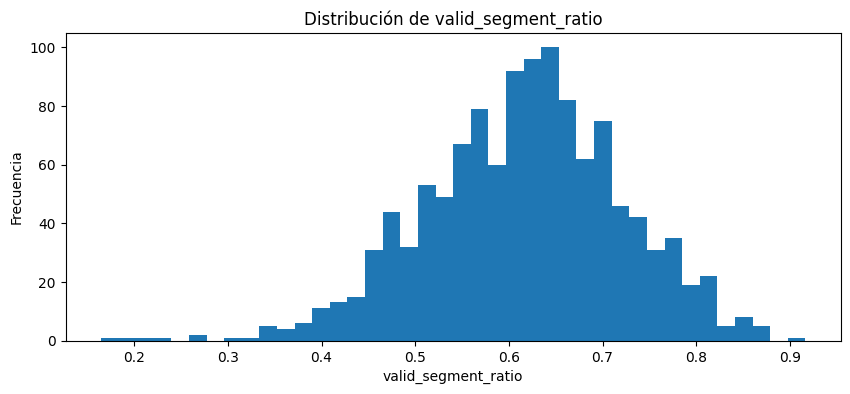

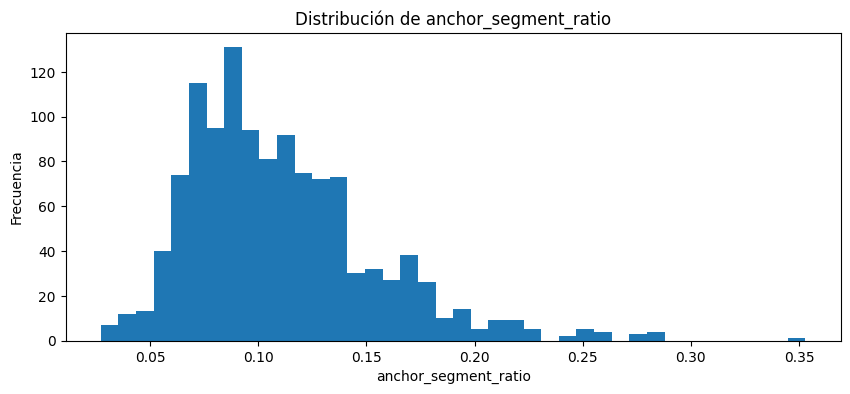

,count,mean,std,min,25%,50%,75%,max
valid_segment_ratio,1198.0,0.616178,0.105948,0.164384,0.54717,0.622222,0.688889,0.916667
anchor_segment_ratio,1198.0,0.110328,0.043056,0.027273,0.08000,0.103448,0.130435,0.352941


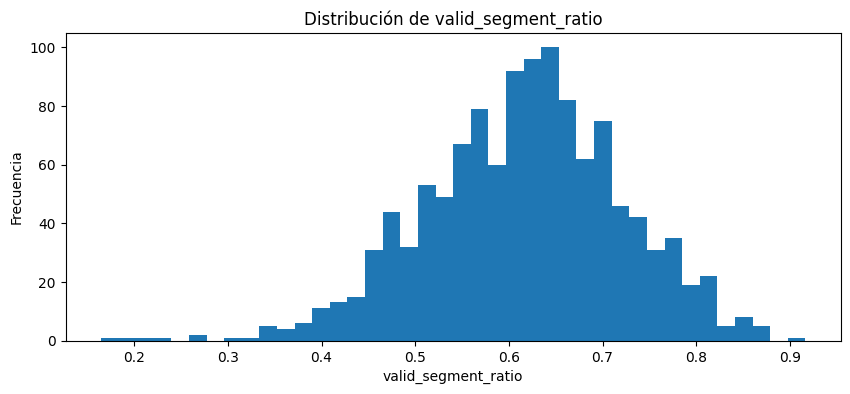

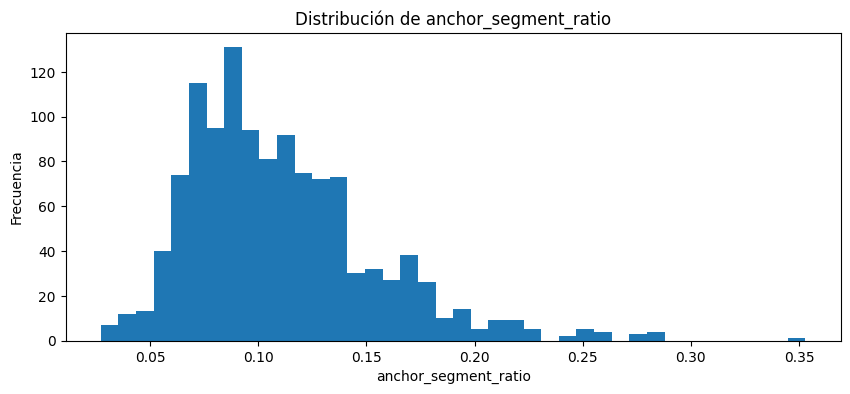

In [10]:
# RATIO DE SEGMENTOS VÁLIDOS Y ANCHORS

df_quality_audio = build_audio_quality_table(df_summary)

quality_columns = [
    column
    for column in [
        "valid_segment_ratio",
        "anchor_segment_ratio",
    ]
    if column in df_quality_audio.columns
]

if quality_columns:
    display(df_quality_audio[quality_columns].describe().T)

    for column in quality_columns:
        plt.figure(figsize=(10, 4))
        plt.hist(df_quality_audio[column].dropna(), bins=40)
        plt.xlabel(column)
        plt.ylabel("Frecuencia")
        plt.title(f"Distribución de {column}")
        plt.show()

## 4. Calidad de segmentos y solapamiento

count    73000.000000
mean         0.138958
std          0.301492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.063291
max          1.000000
Name: overlap_ratio, dtype: float64


,threshold,n_segments_leq,pct_segments_leq,n_segments_gt,pct_segments_gt
0,0.00,48208,0.660384,24792,0.339616
1,0.01,49506,0.678164,23494,0.321836
2,0.03,51970,0.711918,21030,0.288082
3,0.05,53777,0.736671,19223,0.263329
4,0.10,56865,0.778973,16135,0.221027
5,0.15,58817,0.805712,14183,0.194288
6,0.20,60269,0.825603,12731,0.174397
7,0.30,62026,0.849671,10974,0.150329


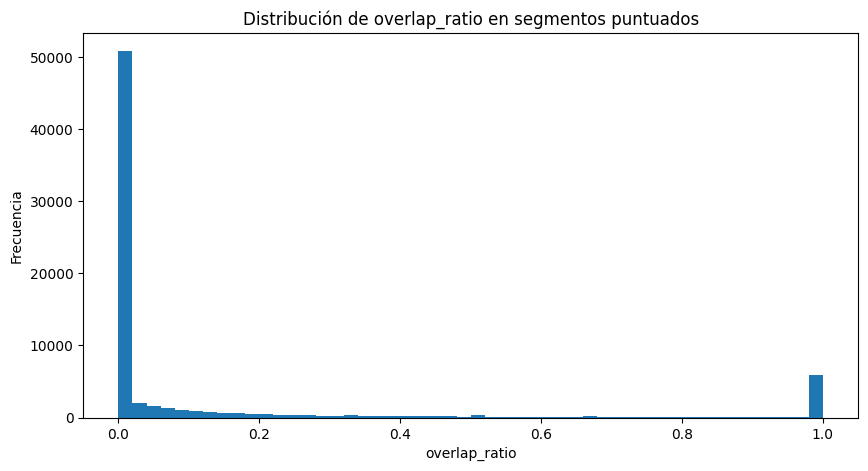

In [11]:
# DISTRIBUCIÓN DE OVERLAP EN SEGMENTOS PUNTUADOS

if "overlap_ratio" in df_all_scored_segments.columns:
    print(df_all_scored_segments["overlap_ratio"].describe())

    overlap_thresholds = [
        0.00,
        0.01,
        0.03,
        0.05,
        0.10,
        0.15,
        0.20,
        0.30,
    ]

    df_overlap_threshold_summary = build_overlap_threshold_summary(
        df_all_scored_segments,
        overlap_thresholds,
    )
    display(df_overlap_threshold_summary)

    plt.figure(figsize=(10, 5))
    plt.hist(
        df_all_scored_segments["overlap_ratio"].dropna(),
        bins=50,
    )
    plt.xlabel("overlap_ratio")
    plt.ylabel("Frecuencia")
    plt.title(
        "Distribución de overlap_ratio "
        "en segmentos puntuados"
    )
    plt.show()
else:
    df_overlap_threshold_summary = pd.DataFrame()
    print("No existe overlap_ratio en df_all_scored_segments.")

In [12]:
# SEGMENTOS CANDIDATOS PARA HUELLA DE VOZ

df_base_for_voiceprint = (
    df_final_segments_meta
    if not df_final_segments_meta.empty
    else df_all_valid_segments_meta
)

(
    df_voiceprint_segments,
    missing_voiceprint_columns,
    speaker_label_column,
) = select_voiceprint_segments(
    df_base_for_voiceprint,
    min_duration=MIN_DURATION_FOR_VOICEPRINT,
    max_overlap_ratio=MAX_OVERLAP_RATIO_FOR_VOICEPRINT,
    min_rms_dbfs=MIN_RMS_DBFS_FOR_VOICEPRINT,
)

if missing_voiceprint_columns:
    print(
        "No se puede aplicar el filtro completo. "
        f"Faltan columnas: {missing_voiceprint_columns}"
    )
else:
    print("Segmentos base:", len(df_base_for_voiceprint))
    print(
        "Segmentos candidatos para huella:",
        len(df_voiceprint_segments),
    )

    if len(df_base_for_voiceprint) > 0:
        print(
            "Porcentaje conservado:",
            f"{len(df_voiceprint_segments) / len(df_base_for_voiceprint):.2%}",
        )

    display(
        df_voiceprint_segments[
            [
                "audio_file",
                speaker_label_column,
                "duration",
                "overlap_ratio",
                "rms_dbfs",
            ]
        ].head()
    )

Segmentos base: 43493
Segmentos candidatos para huella: 27853
Porcentaje conservado: 64.04%


,audio_file,speaker_final,duration,overlap_ratio,rms_dbfs
0,raw_9154117451310006851_clean.wav,SPEAKER_01,4.421250,0.000000,-28.919975
2,raw_9154117451310006851_clean.wav,SPEAKER_01,7.374375,0.000000,-29.186810
4,raw_9154117451310006851_clean.wav,SPEAKER_01,4.708125,0.000000,-27.753717
9,raw_9154117451310006851_clean.wav,SPEAKER_01,2.143125,0.000000,-26.843788
11,raw_9154117451310006851_clean.wav,SPEAKER_00,2.649375,0.012739,-32.090672


## 5. Análisis de relabeling

In [13]:
# RESUMEN DE RELABELING

if (
    not df_final_segments.empty
    and {
        "speaker_original",
        "speaker_final",
    }.issubset(df_final_segments.columns)
):
    df_tmp = df_final_segments.copy()
    df_tmp["was_relabelled"] = (
        df_tmp["speaker_original"] != df_tmp["speaker_final"]
    )

    print("Total segmentos finales:", len(df_tmp))
    print(
        "Segmentos relabelados:",
        int(df_tmp["was_relabelled"].sum()),
    )
    print(
        "Porcentaje relabelado:",
        f"{df_tmp['was_relabelled'].mean():.2%}",
    )

    display(
        df_tmp["was_relabelled"]
        .value_counts(dropna=False)
        .rename_axis("was_relabelled")
        .reset_index(name="n_segments")
    )
else:
    print(
        "No hay columnas speaker_original/speaker_final "
        "o no se cargó df_final_segments."
    )

Total segmentos finales: 43493
Segmentos relabelados: 3700
Porcentaje relabelado: 8.51%


,was_relabelled,n_segments
0,False,39793
1,True,3700


Columna de margen: distance_margin
count    43493.000000
mean         0.346742
std          0.187290
min          0.000003
25%          0.200045
50%          0.345564
75%          0.487432
max          0.930874
Name: distance_margin, dtype: float64


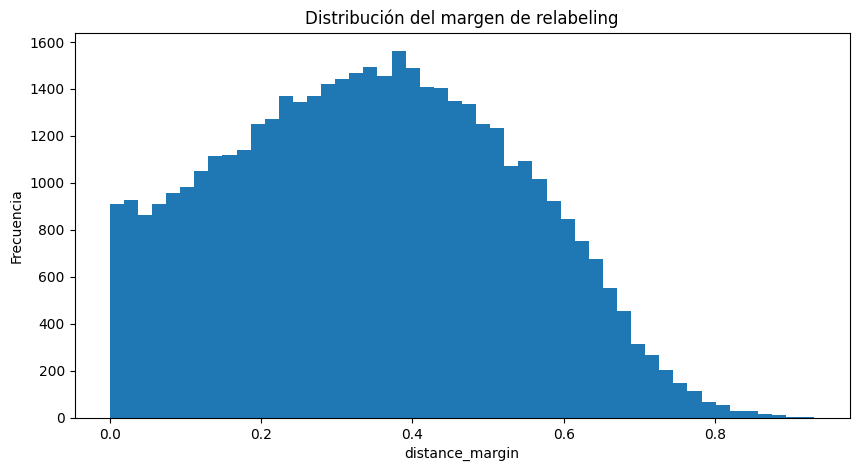


Margen en segmentos que cambiaron:
count    3700.000000
mean        0.152579
std         0.116822
min         0.010009
25%         0.058762
50%         0.121720
75%         0.222748
max         0.698415
Name: distance_margin, dtype: float64


In [14]:
# DISTRIBUCIÓN DEL MARGEN DE RELABELING

margin_column = None

for candidate_column in [
    "distance_margin",
    "similarity_margin",
    "margin",
    "cosine_margin",
    "relabel_margin",
]:
    if (
        not df_final_segments.empty
        and candidate_column in df_final_segments.columns
    ):
        margin_column = candidate_column
        break

if margin_column is not None:
    print("Columna de margen:", margin_column)
    print(df_final_segments[margin_column].describe())

    plt.figure(figsize=(10, 5))
    plt.hist(
        df_final_segments[margin_column].dropna(),
        bins=50,
    )
    plt.xlabel(margin_column)
    plt.ylabel("Frecuencia")
    plt.title("Distribución del margen de relabeling")
    plt.show()

    if (
        not df_changed_segments.empty
        and margin_column in df_changed_segments.columns
    ):
        print("\nMargen en segmentos que cambiaron:")
        print(df_changed_segments[margin_column].describe())
else:
    print(
        "No se encontró columna de margen "
        "en df_final_segments."
    )

## 6. Embeddings de anchors

Primero se intenta usar `all_anchor_embeddings.csv` si contiene vectores. Si solo contiene metadata, se carga `final_relabel/embedding_vectors_csv/all_anchor_embeddings_vectors.csv`. La reconstrucción desde audio permanece desactivada por defecto.

In [15]:
# DIAGNÓSTICO Y CARGA DE EMBEDDINGS VECTORIALES

embedding_columns = detect_embedding_columns(
    df_anchor_embeddings_meta
)

print(
    "Columnas vectoriales detectadas "
    "en df_anchor_embeddings_meta:",
    len(embedding_columns),
)

if embedding_columns:
    df_anchor_embeddings_vectors = (
        df_anchor_embeddings_meta.copy()
    )
    df_anchor_embeddings_vectors_meta = (
        df_anchor_embeddings_meta.copy()
    )
    embedding_cache_path_used = (
        EVALUATION_ANCHOR_EMBEDDINGS_CSV
    )
else:
    (
        df_anchor_embeddings_vectors,
        embedding_cache_path_used,
    ) = load_embedding_vector_cache([
        EVALUATION_ANCHOR_EMBEDDING_VECTORS_CSV,
        LEGACY_ANCHOR_EMBEDDING_VECTORS_CSV,
    ])

    df_anchor_embeddings_vectors_meta = (
        merge_inventory_metadata(
            df_anchor_embeddings_vectors,
            df_inventory_small,
        )
        if not df_anchor_embeddings_vectors.empty
        else pd.DataFrame()
    )

    embedding_columns = detect_embedding_columns(
        df_anchor_embeddings_vectors_meta
    )

if embedding_columns:
    print("Embeddings vectoriales disponibles.")
    print(
        "Cache utilizado:",
        embedding_cache_path_used,
    )
    print(
        "Filas con embeddings:",
        len(df_anchor_embeddings_vectors_meta),
    )
    print(
        "Dimensión del embedding:",
        len(embedding_columns),
    )

    metadata_columns = [
        column
        for column in [
            "audio_file",
            "audio_stem",
            "audio_base",
            "start",
            "end",
            "duration",
            "speaker_final",
            "speaker",
            "anchor_rank",
            "source_dataset_parsed",
            "audio_id_parsed",
            "customer_hash",
            "agent_hash",
        ]
        if column
        in df_anchor_embeddings_vectors_meta.columns
    ]

    display(
        df_anchor_embeddings_vectors_meta[
            metadata_columns + embedding_columns[:5]
        ].head()
    )
else:
    print("No se detectaron embeddings vectoriales.")
    print(
        "Archivo esperado:",
        EVALUATION_ANCHOR_EMBEDDING_VECTORS_CSV,
    )
    print(
        "La diarización y el relabeling no se vuelven "
        "a ejecutar por este motivo."
    )

Columnas vectoriales detectadas en df_anchor_embeddings_meta: 0
Embeddings vectoriales disponibles.
Cache utilizado: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel/embedding_vectors_csv/all_anchor_embeddings_vectors.csv
Filas con embeddings: 7038
Dimensión del embedding: 256


,audio_file,audio_stem,start,end,duration,speaker,anchor_rank,source_dataset_parsed,audio_id_parsed,customer_hash,agent_hash,emb_0000,emb_0001,emb_0002,emb_0003,emb_0004
0,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,120.147219,123.555969,3.408750,SPEAKER_00,1,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.027094,0.026547,0.075299,0.026105,0.036727
1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,72.171594,75.360969,3.189375,SPEAKER_00,2,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,0.043530,-0.042951,0.077997,-0.022896,0.054396
2,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,124.230969,127.285344,3.054375,SPEAKER_00,3,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.066450,-0.047798,-0.014950,0.040734,-0.009607
3,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,94.564719,102.951594,8.386875,SPEAKER_01,1,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.102441,-0.030891,0.033558,-0.017700,0.062358
4,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,6.426594,13.800969,7.374375,SPEAKER_01,2,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.096318,-0.057578,0.002733,-0.012004,0.039952


In [16]:
# RECONSTRUCCIÓN OPCIONAL DE EMBEDDINGS DE ANCHORS

if REBUILD_ANCHOR_EMBEDDINGS and not embedding_columns:
    if not HF_TOKEN:
        raise ValueError(
            "No se encontró HF_TOKEN en el archivo .env."
        )

    import torch
    from pyannote.audio.pipelines.speaker_verification import (
        PretrainedSpeakerEmbedding,
    )

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    embedding_model = PretrainedSpeakerEmbedding(
        EMBEDDING_MODEL_ID,
        device=device,
        token=HF_TOKEN,
    )

    df_anchor_source = (
        df_anchor_embeddings_meta
        if not df_anchor_embeddings_meta.empty
        else df_all_anchor_segments_meta
    )

    df_anchor_embeddings_vectors = rebuild_anchor_embeddings(
        df_anchor_source,
        embedding_model=embedding_model,
        clean_audio_dir=INPUT_DIR,
        clean_audio_gcs_prefix=GCS_CLEAN_AUDIO_PREFIX,
        gcs_client=gcs_client,
        output_path=(
            EVALUATION_ANCHOR_EMBEDDING_VECTORS_CSV
        ),
        max_anchors=MAX_ANCHORS_TO_REBUILD,
    )

    df_anchor_embeddings_vectors = add_audio_keys(
        df_anchor_embeddings_vectors
    )
    df_anchor_embeddings_vectors_meta = (
        merge_inventory_metadata(
            df_anchor_embeddings_vectors,
            df_inventory_small,
        )
    )
    embedding_columns = detect_embedding_columns(
        df_anchor_embeddings_vectors_meta
    )

    print(
        "Embeddings reconstruidos:",
        len(df_anchor_embeddings_vectors_meta),
    )
    print(
        "Dimensión detectada:",
        len(embedding_columns),
    )
elif not embedding_columns:
    print(
        "Reconstrucción omitida porque "
        "REBUILD_ANCHOR_EMBEDDINGS=False."
    )
else:
    print(
        "Reconstrucción innecesaria: "
        "los embeddings ya están disponibles."
    )

Reconstrucción innecesaria: los embeddings ya están disponibles.


In [17]:
# CONSTRUCCIÓN DE CENTROIDES POR AUDIO Y SPEAKER

df_speaker_centroids = build_speaker_centroids(
    df_anchor_embeddings_vectors_meta,
    embedding_columns,
)

if df_speaker_centroids.empty:
    print(
        "No hay embeddings vectoriales disponibles "
        "para construir centroides."
    )
else:
    print(
        "Centroides por audio-speaker:",
        len(df_speaker_centroids),
    )
    display(df_speaker_centroids.head())

Centroides por audio-speaker: 2379


,audio_file,speaker_label,source_dataset_parsed,audio_id_parsed,audio_hash,customer_hash,agent_hash,emb_0000,emb_0001,emb_0002,emb_0003,emb_0004,emb_0005,emb_0006,emb_0007,emb_0008,emb_0009,emb_0010,emb_0011,emb_0012,emb_0013,emb_0014,emb_0015,emb_0016,emb_0017,emb_0018,emb_0019,emb_0020,emb_0021,emb_0022,emb_0023,emb_0024,emb_0025,emb_0026,emb_0027,emb_0028,emb_0029,emb_0030,emb_0031,emb_0032,emb_0033,emb_0034,emb_0035,emb_0036,emb_0037,emb_0038,emb_0039,emb_0040,emb_0041,emb_0042,emb_0043,emb_0044,emb_0045,emb_0046,emb_0047,emb_0048,emb_0049,emb_0050,emb_0051,emb_0052,...,emb_0196,emb_0197,emb_0198,emb_0199,emb_0200,emb_0201,emb_0202,emb_0203,emb_0204,emb_0205,emb_0206,emb_0207,emb_0208,emb_0209,emb_0210,emb_0211,emb_0212,emb_0213,emb_0214,emb_0215,emb_0216,emb_0217,emb_0218,emb_0219,emb_0220,emb_0221,emb_0222,emb_0223,emb_0224,emb_0225,emb_0226,emb_0227,emb_0228,emb_0229,emb_0230,emb_0231,emb_0232,emb_0233,emb_0234,emb_0235,emb_0236,emb_0237,emb_0238,emb_0239,emb_0240,emb_0241,emb_0242,emb_0243,emb_0244,emb_0245,emb_0246,emb_0247,emb_0248,emb_0249,emb_0250,emb_0251,emb_0252,emb_0253,emb_0254,emb_0255
0,raw_9154117451310006851_clean.wav,SPEAKER_00,raw,9154117451310006851,59bbb26cd2aa85af,a9caf51c656e2261,143be6589a2896d9,-0.016671,-0.021401,0.046115,0.014648,0.027172,-0.015883,0.060408,0.060763,0.046380,-0.039998,0.054370,0.008827,0.119503,0.032449,-0.041558,-0.076509,-0.038491,-0.045617,0.109906,-0.052769,-0.030406,0.034651,0.028275,-0.046187,0.038471,0.024507,0.009689,-0.053985,-0.069735,-0.023730,0.034492,-0.022757,0.020854,0.009771,-0.007775,0.063469,-0.069029,-0.093548,0.015868,-0.011128,-0.049547,0.079051,-0.019678,-0.059762,0.049905,0.014655,0.014751,-0.044547,0.048383,-0.003220,0.071744,-0.025407,0.064604,...,0.042976,0.133426,0.121770,0.030549,-0.023876,-0.072669,-0.063328,-0.006402,0.101307,-0.007614,0.018428,-0.108993,0.010866,-0.006758,0.011562,0.093638,-0.044052,0.067504,-0.035639,0.046077,-0.027347,-0.017807,-0.049941,-0.009797,0.032019,-0.013157,-0.037534,0.025016,-0.063436,0.012801,-0.015536,-0.020719,0.031388,-0.048039,0.044353,0.005946,0.047173,0.011885,0.040263,-0.023793,0.004179,0.049141,0.003074,-0.101301,-0.080124,0.023719,0.036512,-0.015601,-0.046366,0.034662,-0.066447,-0.093570,0.022309,0.088403,-0.042307,-0.052641,0.026603,0.042358,0.054615,0.074517
1,raw_9154117451310006851_clean.wav,SPEAKER_01,raw,9154117451310006851,59bbb26cd2aa85af,a9caf51c656e2261,143be6589a2896d9,-0.078049,-0.048847,0.021524,-0.017002,0.050379,-0.030390,0.050010,-0.080472,0.022884,-0.034037,0.012322,-0.046052,0.096104,-0.010394,-0.105343,0.007324,-0.057885,-0.002745,0.089813,-0.035525,-0.083223,0.042355,0.138273,0.010194,-0.028473,0.071480,0.058078,0.110897,0.008102,0.035147,0.037955,0.005910,-0.077448,0.000735,-0.038325,0.010542,-0.058070,0.070357,0.077279,-0.110100,0.106458,0.124732,0.072725,-0.022015,0.025047,0.122024,0.045591,0.066032,0.025897,-0.025659,-0.014142,0.053715,0.013039,...,-0.041787,0.085959,-0.004963,-0.106535,0.068608,0.007743,0.002059,0.005166,0.092951,0.070787,0.114927,-0.063910,-0.072011,0.081229,-0.031074,0.009362,-0.019090,0.133272,0.025630,-0.058019,-0.074886,-0.124407,0.009007,-0.012763,0.091241,-0.054458,0.048417,0.069943,-0.081113,-0.025879,0.013254,-0.200145,0.021612,-0.011987,0.115400,-0.062712,0.028432,0.031564,0.018931,-0.071970,0.023691,0.024193,0.097484,-0.090494,-0.052417,-0.014986,0.067165,0.000793,-0.164622,-0.086053,0.005085,0.044151,0.002606,-0.045316,-0.077138,-0.016470,0.070437,-0.011923,-0.035852,-0.029379
2,raw_9154117551220006851_clean.wav,SPEAKER_00,raw,9154117551220006851,279636e636f34590,73e95b4635bee260,022ea603159275cd,-0.101912,-0.060621,0.003128,-0.063772,-0.026202,0.027713,0.028787,0.086838,-0.033708,-0.037221,-0.048758,-0.036350,0.073712,-0.011737,-0.088049,0.011226,-0.068542,-0.032441,0.097463,-0.014886,-0.110760,0.007993,0.092618,0.035409,-0.049210,0.025909,0.027954,0.067671,-0.031484,0.013030,0.004783,0.024020,-0.153103,0.041280,-0.093027,-0.050586,-0.041777,0.037091,0.0511

## 7. Evaluación proxy por identidad

,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por customer_hash,20224,224,20000,0.735689,0.583443,0.765288,0.595495,0.828227


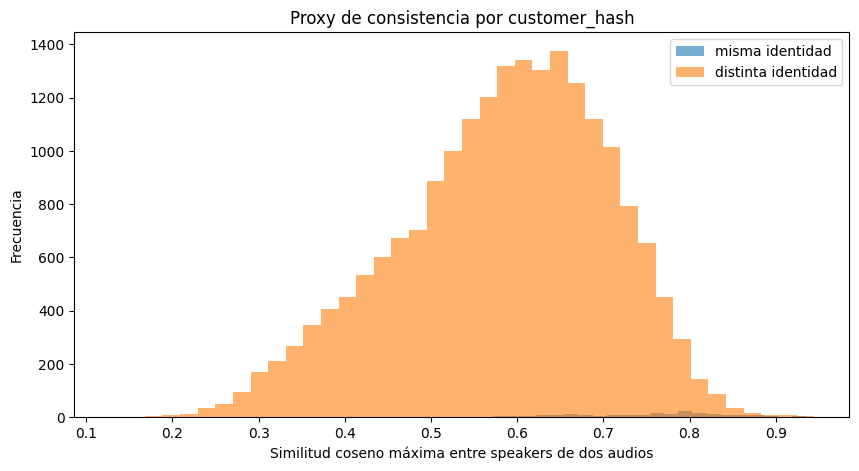

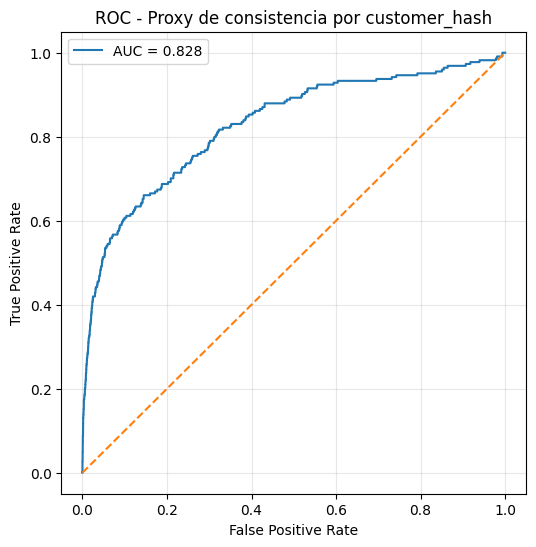

,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por customer_hash,20224,224,20000,0.735689,0.583443,0.765288,0.595495,0.828227


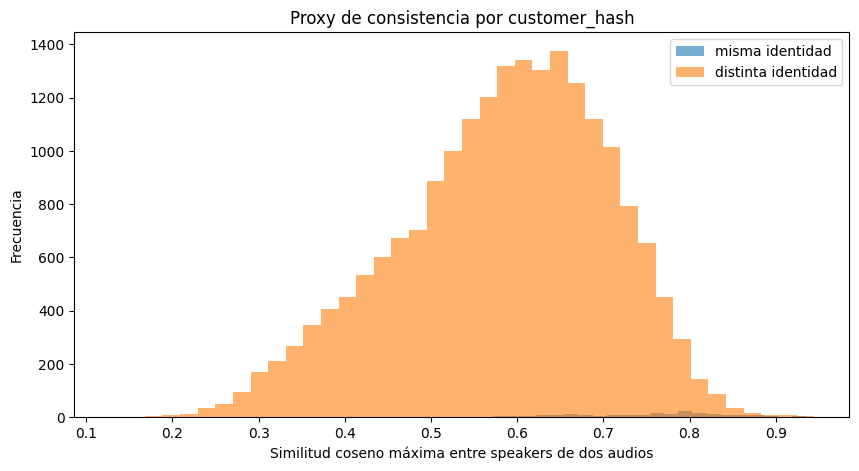

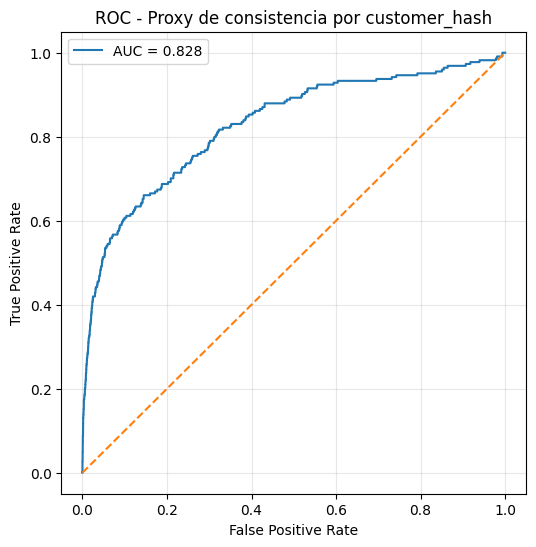

In [18]:
# EVALUACIÓN PROXY POR CUSTOMER_HASH

proxy_summaries = []

if (
    not df_speaker_centroids.empty
    and "customer_hash" in df_speaker_centroids.columns
):
    df_customer_pairs = build_proxy_pairs(
        df_centroids=df_speaker_centroids,
        identity_column="customer_hash",
        embedding_columns=embedding_columns,
        max_pairs_per_identity=MAX_PAIRS_PER_IDENTITY,
        max_negative_pairs=MAX_NEGATIVE_PAIRS,
    )

    summary_customer = summarize_proxy_pairs(
        df_customer_pairs,
        "Proxy de consistencia por customer_hash",
    )

    if summary_customer is not None:
        proxy_summaries.append(summary_customer)
        display(pd.DataFrame([summary_customer]))
        plot_proxy_pair_evaluation(
            df_customer_pairs,
            "Proxy de consistencia por customer_hash",
        )
    else:
        print("No hay pares para customer_hash.")
else:
    df_customer_pairs = pd.DataFrame()
    print(
        "No se puede evaluar customer_hash: "
        "faltan centroides o metadata."
    )

,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por agent_hash,21524,1524,20000,0.822671,0.598834,0.845665,0.611304,0.936423


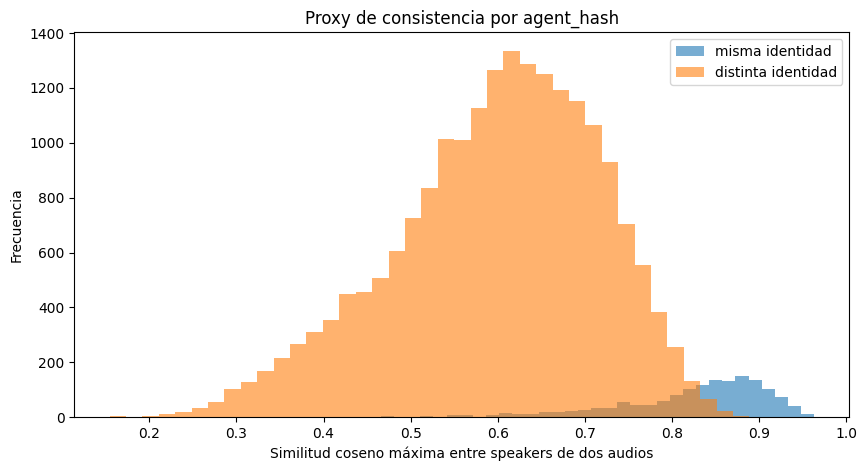

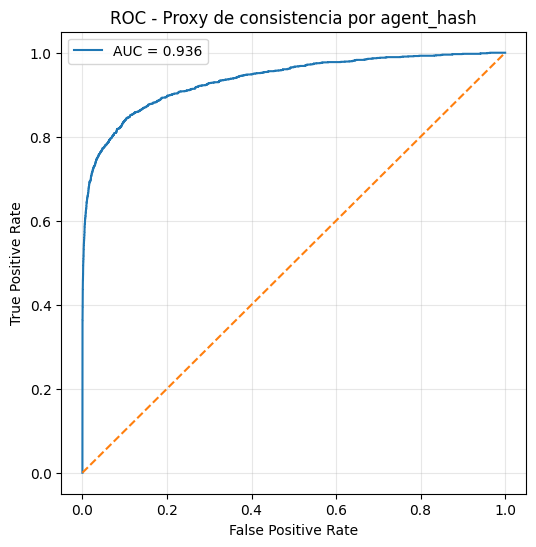

,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por agent_hash,21524,1524,20000,0.822671,0.598834,0.845665,0.611304,0.936423


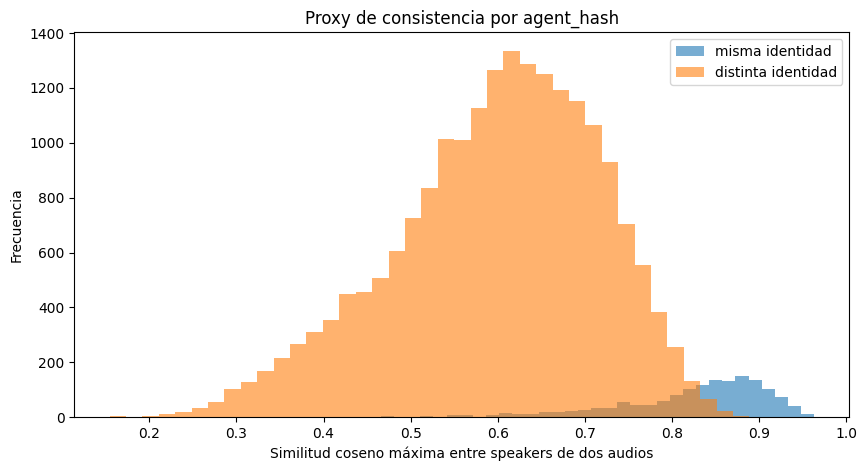

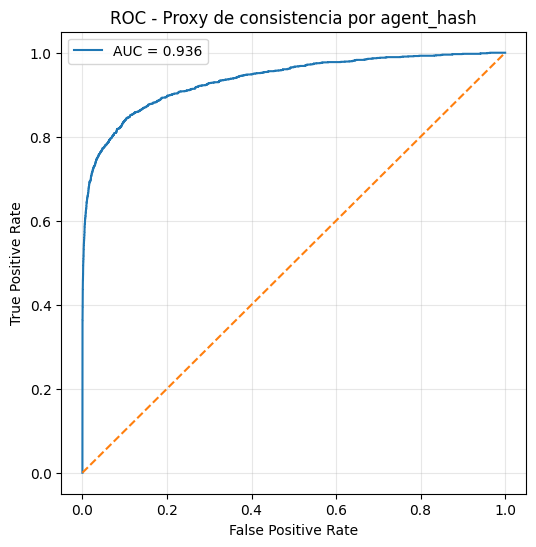

In [19]:
# EVALUACIÓN PROXY POR AGENT_HASH

if (
    not df_speaker_centroids.empty
    and "agent_hash" in df_speaker_centroids.columns
):
    df_agent_pairs = build_proxy_pairs(
        df_centroids=df_speaker_centroids,
        identity_column="agent_hash",
        embedding_columns=embedding_columns,
        max_pairs_per_identity=MAX_PAIRS_PER_IDENTITY,
        max_negative_pairs=MAX_NEGATIVE_PAIRS,
    )

    summary_agent = summarize_proxy_pairs(
        df_agent_pairs,
        "Proxy de consistencia por agent_hash",
    )

    if summary_agent is not None:
        proxy_summaries.append(summary_agent)
        display(pd.DataFrame([summary_agent]))
        plot_proxy_pair_evaluation(
            df_agent_pairs,
            "Proxy de consistencia por agent_hash",
        )
    else:
        print("No hay pares para agent_hash.")
else:
    df_agent_pairs = pd.DataFrame()
    print(
        "No se puede evaluar agent_hash: "
        "faltan centroides o metadata."
    )

In [20]:
# TABLA FINAL DE EVALUACIÓN PROXY

df_proxy_summary = pd.DataFrame(proxy_summaries)

if not df_proxy_summary.empty:
    display(df_proxy_summary)
else:
    print("No se generó resumen proxy.")

,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por customer_hash,20224,224,20000,0.735689,0.583443,0.765288,0.595495,0.828227
1,Proxy de consistencia por agent_hash,21524,1524,20000,0.822671,0.598834,0.845665,0.611304,0.936423


,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por customer_hash,20224,224,20000,0.735689,0.583443,0.765288,0.595495,0.828227
1,Proxy de consistencia por agent_hash,21524,1524,20000,0.822671,0.598834,0.845665,0.611304,0.936423


## 8. Interpretación

Si la diarización y la selección de anchors funcionan razonablemente, se espera que las similitudes de pares con la misma identidad sean mayores que las de identidades distintas y que el AUC sea superior a 0,50.

La evaluación por `agent_hash` puede ser más informativa cuando un agente aparece en varias llamadas. La evaluación por `customer_hash` puede ser limitada cuando la mayoría de clientes solo tienen una llamada.

Esta evaluación sigue siendo un proxy: utiliza la similitud máxima entre speakers de dos audios porque todavía no existe un mapeo validado entre `speaker_final` y el rol real cliente/agente. La evaluación formal con DER/JER requiere una referencia temporal validada.

In [21]:
# SUBIDA FINAL DE OUTPUTS NUEVOS O MODIFICADOS A GCS

# Incondicional: skip_unchanged=True evita resubir lo que ya está igual en GCS.
upload_directory(
    local_dir=EMBEDDING_VECTOR_CSV_DIR,
    gcs_prefix=GCS_EMBEDDING_VECTOR_PREFIX,
    gcs_client=gcs_client,
    clear_output_fn=clear_output,
    skip_unchanged=True,
)

Subida final completada.
Archivos locales revisados: 2381
Archivos subidos: 0
Archivos omitidos sin cambios: 2381
Destino: gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/final_relabel/embedding_vectors_csv/


{'total': 2381, 'uploaded': 0, 'skipped': 2381}